# Taller — Construye y ajusta tu propio clasificador de imágenes

Este taller comienza **después de la teoría de CNN y del notebook guiado de transfer learning**.

La meta no es memorizar la API de Keras. La meta es tomar decisiones sobre un problema real: construir datos propios, adaptar un modelo preentrenado y analizar qué tan bien funciona.

---

## Organización de la actividad

| Momento | Tiempo estimado | Meta |
|---|---:|---|
| **Teoría + notebook guiado** | Se realiza antes de este taller | Comprender CNN, transfer learning y fine-tuning |
| **Trabajo en clase** | ~60 min | Construir el dataset y entrenar el primer modelo con la base congelada |
| **Trabajo en casa** | ~1–2 h | Evaluar, hacer fine-tuning, comparar y analizar errores |

### Regla importante

Durante el trabajo en clase usaremos **train** y **validation**.  
El conjunto de **test** se reservará para el trabajo en casa, cuando hagamos la evaluación final.

---

## Entrega final

Debes entregar **este mismo notebook ejecutado**, incluyendo:

- definición del problema y estrategia de búsqueda;
- dataset propio;
- primer entrenamiento con transfer learning;
- evaluación en test;
- fine-tuning;
- comparación antes/después;
- matriz de confusión;
- análisis de al menos 5 errores;
- conclusiones.

## 0. Preparación del entorno

La búsqueda de imágenes se realizará con `ddgs`. Si estás en Google Colab, ejecuta la siguiente celda.

In [1]:
!pip -q install -U ddgs

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import hashlib, io, random, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

import tensorflow as tf
import keras
from keras import layers
from ddgs import DDGS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Keras: 3.15.1
TensorFlow: 2.21.0


GPU: []


# PARTE A — TRABAJO EN CLASE (~60 min)

## Objetivo de esta parte

Antes de terminar la sesión debes haber conseguido:

1. definir un problema de clasificación de 3 clases;
2. descargar y revisar un dataset propio;
3. separar los datos en `train`, `validation` y `test`;
4. cargar EfficientNetB0 preentrenada en ImageNet;
5. congelar el backbone;
6. entrenar una nueva cabeza de clasificación;
7. observar `accuracy` y `val_accuracy`.

> **No evalúes todavía sobre `test`.** Ese conjunto queda reservado para el trabajo en casa.

### Distribución sugerida

- **10 min** — problema y términos de búsqueda;
- **20 min** — descarga, inspección y limpieza;
- **10 min** — separación y carga del dataset;
- **20 min** — transfer learning y primer entrenamiento.

# 1. Define tu problema — EN CLASE

Elige un problema de clasificación de **3 clases**. Las clases deben ser visualmente distinguibles.

Ejemplos: `espresso/cappuccino/latte`, `bus/motorcycle/bicycle`, tres especies de flores, frutas, tipos de calzado o instrumentos musicales.

Evita problemas donde la clase dependa de información que no aparece visualmente en la imagen.

## TODO 1 — Problema y estrategia de búsqueda

Define:

1. las tres clases;
2. dos o tres términos de búsqueda por clase;
3. una breve hipótesis: **¿qué características visuales esperas que use el modelo?**;
4. un posible sesgo o fuente de *data leakage* que podría aparecer al descargar imágenes desde un buscador.

In [2]:
# TODO 1 — EN CLASE: define tus clases y búsquedas
# Tres clases de vehículos de dos o más ruedas; se busca explícitamente
# "photo" y contextos variados (calle, estacionado, de lado) para evitar
# dibujos, logos y fotos de catálogo con fondo blanco.
SEARCHES = {
    "bicycle": [
        "bicycle parked on street photo",
        "person riding bicycle city photo",
        "road bike side view photo",
    ],
    "bus": [
        "city bus on street photo",
        "public transit bus stop photo",
        "double decker bus photo",
    ],
    "motorcycle": [
        "motorcycle parked on street photo",
        "person riding motorcycle road photo",
        "motorbike side view photo",
    ],
}

SEARCHES

{'bicycle': ['bicycle parked on street photo',
  'person riding bicycle city photo',
  'road bike side view photo'],
 'bus': ['city bus on street photo',
  'public transit bus stop photo',
  'double decker bus photo'],
 'motorcycle': ['motorcycle parked on street photo',
  'person riding motorcycle road photo',
  'motorbike side view photo']}

### Antes de descargar

Escribe debajo de esta celda una respuesta corta:

- ¿Qué características visuales esperas que diferencien tus clases?
- ¿Qué imágenes incorrectas esperas encontrar?
- ¿Qué sesgo o *data leakage* podría aparecer?

**Respuesta (antes de descargar):**

- **Características visuales esperadas:** el **número y tamaño de las ruedas** respecto al cuerpo del vehículo; el **volumen**: un bus es una caja grande con muchas ventanas laterales, mientras que bicicleta y moto son estructuras delgadas; la **presencia de motor, tanque y carenado** (moto) frente a un **cuadro de tubos finos, pedales y cadena** (bicicleta); y la **escala respecto a las personas**: el bus es mucho más grande que el humano, y en la bici y la moto el humano está encima.
- **Imágenes incorrectas esperadas:** dibujos, iconos o renders 3D; motos eléctricas o scooters que parecen bicicletas (y bicicletas eléctricas que parecen motos); juguetes y maquetas; fotos de catálogo con fondo blanco; imágenes con varios vehículos de distintas clases; collages; y anuncios con texto.
- **Sesgo / data leakage:**
  - **Fondo correlacionado con la clase**: los buses aparecen casi siempre en calles urbanas con edificios, y las motos de catálogo en estudio, así que el modelo podría aprender el fondo en lugar del vehículo.
  - **Texto que revela la etiqueta**: rótulos de rutas en los buses, marcas de motos.
  - **Casi-duplicados**: la misma foto en distintos tamaños o recortes que el hash exacto no detecta. Si una copia cae en train y otra en test, la métrica de test queda inflada.
  - Los buscadores priorizan imágenes "bonitas" y de stock, así que el dataset no representa bien fotos reales tomadas con celular.

# 2. Buscar y descargar imágenes — EN CLASE

La siguiente función busca imágenes y descarga los resultados. Intenta ignorar URLs fallidas, verificar las imágenes, evitar duplicados exactos con un hash y convertirlas a RGB.

> Se solicita contenido con licencia Creative Commons cuando el motor lo soporta. Eso no sustituye la revisión de licencias si el dataset se va a redistribuir.

In [3]:
RAW_DIR = Path("data_raw")
RAW_DIR.mkdir(exist_ok=True)

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def download_image_dataset(searches, root=RAW_DIR, images_per_query=60, min_side=120, timeout=8):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    # Incluye imágenes de ejecuciones anteriores para que volver a ejecutar
    # la descarga no agregue duplicados exactos al dataset.
    seen_hashes = {
        file_sha256(path)
        for path in Path(root).glob("*/*.jpg")
        if path.is_file()
    }

    for class_name, queries in searches.items():
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        saved = len(list(class_dir.glob("*.jpg")))
        print(f"\n=== {class_name} ===")

        for query in queries:
            print(f"Buscando: {query!r}")
            try:
                results = DDGS().images(
                    query=query,
                    safesearch="moderate",
                    max_results=images_per_query,
                    license_image="any",
                )
            except Exception as e:
                print("  Error en búsqueda:", e)
                continue

            for result in results:
                url = result.get("image")
                if not url:
                    continue
                try:
                    response = session.get(url, timeout=timeout)
                    response.raise_for_status()
                    data = response.content
                    digest = hashlib.sha256(data).hexdigest()
                    if digest in seen_hashes:
                        continue

                    with Image.open(io.BytesIO(data)) as img:
                        img = img.convert("RGB")
                        if min(img.size) < min_side:
                            continue
                        filename = class_dir / f"{saved:04d}.jpg"
                        img.save(filename, format="JPEG", quality=90)

                    seen_hashes.add(digest)
                    saved += 1
                except Exception:
                    pass

            print(f"  Total guardadas hasta ahora: {saved}")
            time.sleep(1)

    print("\nDescarga terminada.")

## TODO 2 — EN CLASE: construye y limpia tu dataset

Tu objetivo inicial es obtener aproximadamente **100–150 imágenes útiles por clase**.

1. Ejecuta la descarga.
2. Inspecciona muestras aleatorias.
3. Mejora los términos de búsqueda si una clase trae resultados pobres.
4. Elimina imágenes claramente incorrectas o problemáticas.
5. Reporta el número final de imágenes por clase y describe el error más frecuente que encontraste.

> Si la búsqueda trae datos malos, **no aumentes simplemente `max_results`**. Primero mejora los términos de búsqueda.

In [5]:
# TODO 2 — EN CLASE: ejecuta la descarga con tus búsquedas
download_image_dataset(
    SEARCHES,
    images_per_query=60,
)


=== bicycle ===
Buscando: 'bicycle parked on street photo'


C:\Users\jhonp\.venvs\tf312\Lib\site-packages\PIL\Image.py:1136: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Total guardadas hasta ahora: 31


Buscando: 'person riding bicycle city photo'


  Total guardadas hasta ahora: 66


...

Buscando: 'person riding motorcycle road photo'


  Total guardadas hasta ahora: 69


Buscando: 'motorbike side view photo'


  Total guardadas hasta ahora: 103



Descarga terminada.


In [6]:
def count_images(root):
    counts = {}
    for folder in sorted(Path(root).iterdir()):
        if folder.is_dir():
            counts[folder.name] = len(list(folder.glob("*.jpg")))
    return counts

count_images(RAW_DIR)

{'bicycle': 101, 'bus': 100, 'motorcycle': 103}

## Validación técnica automática de las imágenes

Antes de inspeccionar el contenido del dataset, comprobaremos que **TensorFlow pueda decodificar todas las imágenes**.

Esto resuelve un problema distinto al de la inspección visual:

- **Validación técnica:** ¿el archivo puede ser leído correctamente por TensorFlow?
- **Validación semántica:** ¿la imagen realmente pertenece a la clase indicada?

Una imagen puede abrirse aparentemente bien en otras librerías y aun así fallar durante `model.fit()`. Por eso hacemos esta comprobación usando el mismo decoder que utilizará el pipeline de Keras.

In [5]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*.jpg"):
        try:
            raw = tf.io.read_file(str(path))

            img = tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False,
            )

            # Forzamos la ejecución para detectar errores de decodificación.
            _ = img.numpy()

        except Exception as e:
            print("Imagen inválida:", path)
            print(" ", str(e).splitlines()[0])
            bad_files.append(path)

    for path in bad_files:
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

    return bad_files


bad_files = remove_invalid_images(RAW_DIR)


Imágenes inválidas eliminadas: 0


### Verificación

Ejecuta nuevamente la función. El resultado esperado es:

```text
Imágenes inválidas eliminadas: 0
```

Si todavía aparece alguna imagen inválida, vuelve a ejecutar hasta obtener cero antes de continuar.

In [6]:
bad_files = remove_invalid_images(RAW_DIR)

assert len(bad_files) == 0, (
    "Todavía quedan imágenes que TensorFlow no puede decodificar."
)

print("✓ Todas las imágenes pueden ser decodificadas por TensorFlow.")


Imágenes inválidas eliminadas: 0
✓ Todas las imágenes pueden ser decodificadas por TensorFlow.


# 3. Inspección y limpieza semántica — EN CLASE

La etapa anterior confirmó que los archivos son **técnicamente válidos**.

Ahora viene una tarea diferente: comprobar si los datos son **semánticamente correctos**.

Busca especialmente:

- imágenes que no correspondan a la clase;
- dibujos, logos o diagramas si tu objetivo son fotografías;
- imágenes con texto que pueda revelar artificialmente la etiqueta;
- duplicados o imágenes casi idénticas;
- fondos que estén correlacionados con una clase;
- diferencias sistemáticas de estilo o calidad entre clases.

> Que TensorFlow pueda abrir una imagen no significa que sea un buen dato de entrenamiento.

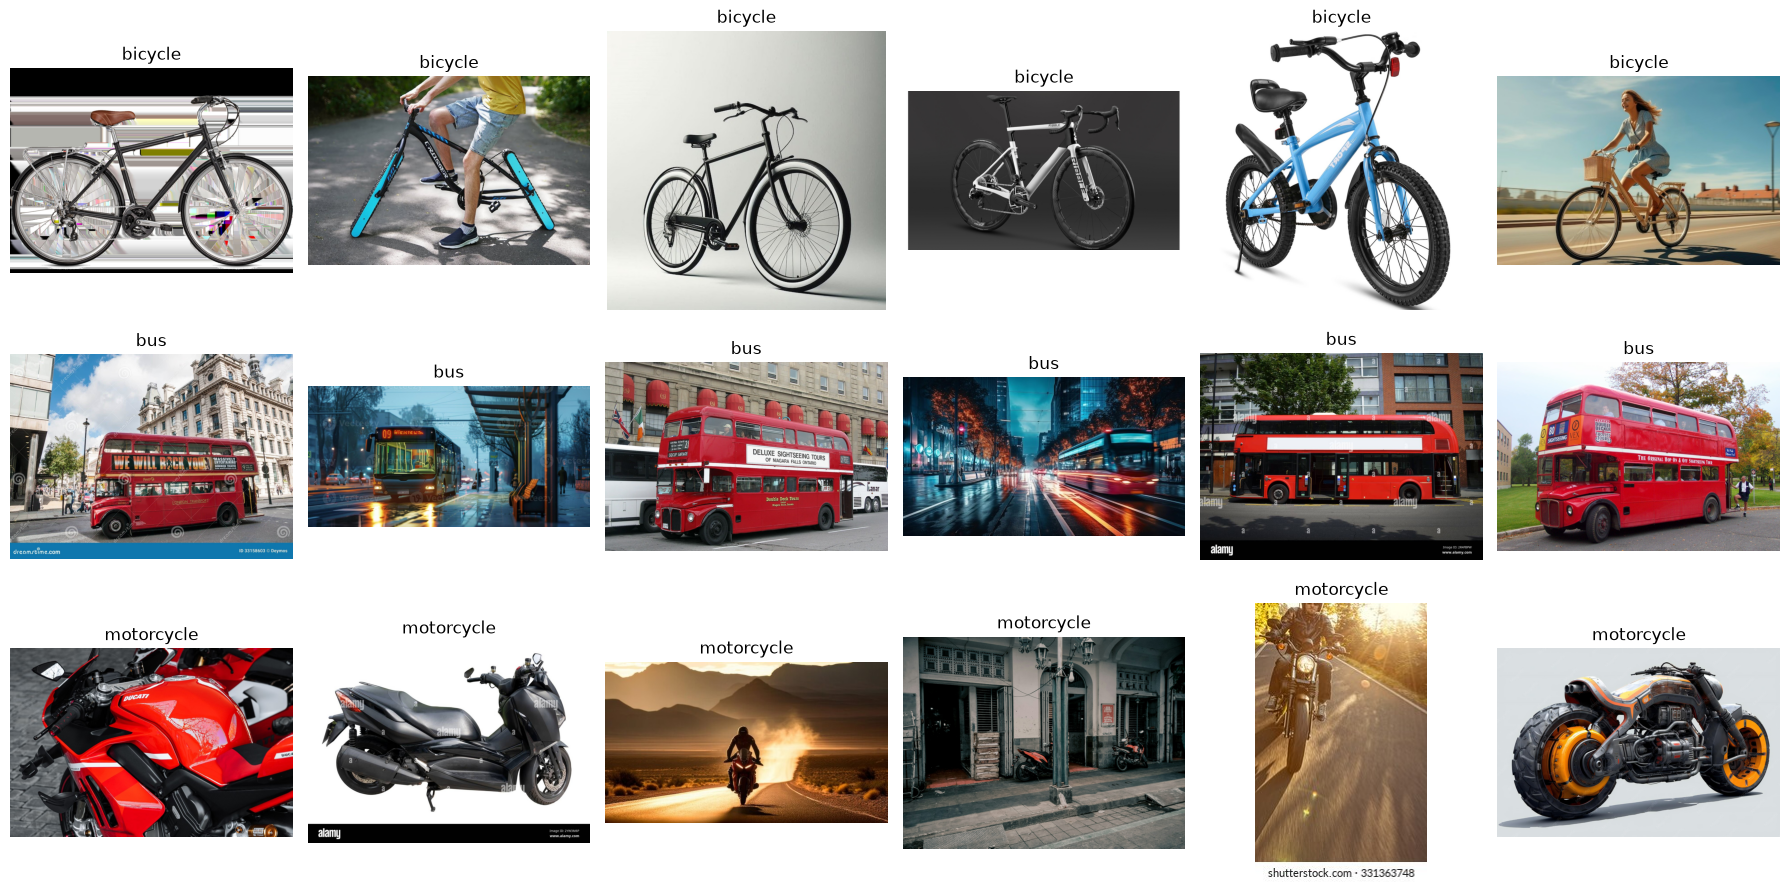

In [9]:
def show_random_images(root, n_per_class=6):
    root = Path(root)
    class_dirs = [p for p in sorted(root.iterdir()) if p.is_dir()]
    fig, axes = plt.subplots(len(class_dirs), n_per_class, figsize=(3*n_per_class, 3*len(class_dirs)))
    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, 0)
    for row, class_dir in enumerate(class_dirs):
        files = list(class_dir.glob("*.jpg"))
        chosen = random.sample(files, min(n_per_class, len(files)))
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col])
                ax.imshow(img)
                ax.set_title(class_dir.name)
            ax.axis("off")
    plt.tight_layout()

show_random_images(RAW_DIR)

In [10]:
# Limpieza semántica: imágenes eliminadas tras inspeccionar TODAS las descargas
# (hojas de contacto con las ~300 imágenes). Cada entrada indica el motivo.
SEMANTIC_REMOVALS = {
    "bicycle": {
        "0008": "render 3D / imagen generada, no es foto",
        "0009": "ilustración",
        "0010": "collage de 4 fotos",
        "0018": "bicicleta novedosa de ruedas cuadradas (atípica)",
        "0019": "render 3D de bicicleta de vidrio",
        "0020": "ilustración con 6 bicicletas",
        "0022": "infografía con texto 'Types of Bicycles'",
        "0062": "silueta a contraluz, la bicicleta casi no se ve",
        "0065": "personaje 3D de caricatura",
        "0075": "collage artístico",
        "0078": "silueta / dibujo vectorial",
        "0081": "cuadrícula de 6 bicicletas",
        "0084": "silueta / dibujo vectorial",
        "0091": "casi-duplicado de 0073 (misma foto, otra marca de agua)",
        "0095": "casi-duplicado de 0077",
        "0096": "ETIQUETA INCORRECTA: es una motocicleta",
        "0100": "ETIQUETA INCORRECTA: rueda de motocicleta",
    },
    "bus": {
        **{k: "paradero sin bus visible (búsqueda 'bus stop')" for k in [
            "0026", "0034", "0035", "0037", "0041", "0042", "0048", "0049",
            "0051", "0052", "0055", "0056", "0059", "0060"]},
        **{k: "caricatura / icono / render de paradero" for k in [
            "0044", "0045", "0046", "0047", "0058", "0061", "0062", "0063", "0064"]},
        **{k: "bus diminuto o irreconocible en la escena" for k in [
            "0013", "0028", "0038", "0053", "0057", "0066"]},
        "0031": "vista desde el interior de un vehículo, sin bus visible",
    },
    "motorcycle": {
        "0020": "muy oscura, motos irreconocibles",
        "0027": "muy oscura, motos irreconocibles",
        "0028": "moto diminuta en la escena",
        "0031": "primer plano parcial de una rueda, irreconocible",
        "0041": "imagen abstracta con moto diminuta",
        "0075": "render de moto concepto",
        "0077": "ilustración",
        "0081": "render 3D",
        "0095": "collage de vistas con texto",
        "0096": "primer plano del motor, sin contexto",
    },
}

removed = 0
for class_name, files in SEMANTIC_REMOVALS.items():
    for stem in files:
        path = RAW_DIR / class_name / f"{stem}.jpg"
        if path.exists():
            path.unlink()
            removed += 1

print("Imágenes eliminadas por limpieza semántica:", removed)
print("Imágenes por clase después de limpiar:", count_images(RAW_DIR))

Imágenes eliminadas por limpieza semántica: 57
Imágenes por clase después de limpiar: {'bicycle': 84, 'bus': 70, 'motorcycle': 93}


### Checkpoint del dataset

Antes de continuar, asegúrate de que:

- cada carpeta contiene imágenes realmente asociadas a su clase;
- no predominan logos, dibujos o texto que revele la etiqueta;
- no hay una diferencia de fondo/estilo demasiado obvia entre clases;
- el número de imágenes por clase es razonablemente balanceado.

Registra aquí el número de imágenes eliminadas y el problema de calidad más frecuente.

**Registro de la limpieza:**

| Clase | Descargadas | Eliminadas | Finales |
|---|---:|---:|---:|
| bicycle | 101 | 17 | 84 |
| bus | 100 | 30 | 70 |
| motorcycle | 103 | 10 | 93 |
| **Total** | **304** | **57** | **247** |

Revisé las 304 imágenes con hojas de contacto. Los motivos de cada eliminación están en la celda de limpieza anterior.

- **Problema de calidad más frecuente:** imágenes donde **el objeto de la clase no aparece o no es una foto**. La búsqueda *"public transit bus stop photo"* devolvió sobre todo **paraderos vacíos** e ilustraciones de paraderos: 24 de las 30 eliminaciones de `bus`. En las otras clases predominaron renders 3D, dibujos, siluetas, collages e infografías con texto.
- **Etiquetas incorrectas:** 2 motocicletas aparecieron en la carpeta `bicycle` (0096, 0100).
- **Casi-duplicados:** 2 pares de la misma foto con distinta marca de agua (bicycle 0073/0091 y 0077/0095). Eliminé una copia de cada par para que no cayeran en train y test a la vez.
- **Sesgos que quedan (no eliminados):**
  - La búsqueda *"double decker bus"* trajo casi solo **buses rojos de Londres** (~1/3 de la clase `bus`), así que el modelo podría usar el **color rojo / estilo londinense** como atajo.
  - Muchas imágenes de ciclistas urbanos tienen el mismo **estilo de imagen generada por IA** (atardecer, desenfoque de movimiento).
  - Hay **marcas de agua** (alamy, shutterstock, dreamstime) en las tres clases, aunque la franja azul de dreamstime aparece sobre todo en `bus`.
- **Balance:** 84 / 70 / 93. La clase `bus` quedó algo por debajo, pero el desbalance es moderado (≈ 1.3 : 1).

# 4. Separar train, validation y test — EN CLASE

> **Concepto clave — tres conjuntos, tres funciones**
>
> - **Train:** se utiliza para actualizar los pesos del modelo.
> - **Validation:** se utiliza durante el desarrollo para decidir épocas, `learning_rate`, número de capas a descongelar, etc.
> - **Test:** se reserva para medir el rendimiento final. No debe guiar las decisiones de entrenamiento.

Usaremos **70 % entrenamiento, 15 % validación y 15 % prueba**.

In [7]:
SPLIT_DIR = Path("dataset")

def split_dataset(source_root, destination_root, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    source_root = Path(source_root)
    destination_root = Path(destination_root)
    if destination_root.exists():
        shutil.rmtree(destination_root)
    rng = random.Random(seed)

    for class_dir in sorted(source_root.iterdir()):
        if not class_dir.is_dir():
            continue
        files = list(class_dir.glob("*.jpg"))
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": files[:n_train],
            "validation": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:],
        }
        for split_name, split_files in splits.items():
            target = destination_root / split_name / class_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target / src.name)

split_dataset(RAW_DIR, SPLIT_DIR)
for split in ["train", "validation", "test"]:
    print(split, count_images(SPLIT_DIR / split))

train {'bicycle': 58, 'bus': 49, 'motorcycle': 65}
validation {'bicycle': 12, 'bus': 10, 'motorcycle': 13}
test {'bicycle': 14, 'bus': 11, 'motorcycle': 15}


### Comprobación conceptual

Explica brevemente: ¿por qué usar repetidamente el conjunto de prueba para escoger épocas, `learning_rate` o capas a descongelar termina contaminando nuestra estimación de desempeño?

**Respuesta:** cada vez que miramos el resultado en test y cambiamos algo por ello (más épocas, otro `learning_rate`, más capas descongeladas), estamos **eligiendo la configuración que mejor le va a esas imágenes concretas**. Con suficientes intentos, algunas configuraciones salen mejor en test **por azar**: aciertan justo los casos particulares de ese conjunto, no porque generalicen mejor. El test pasa a funcionar como un segundo conjunto de validación y su accuracy deja de ser una estimación **imparcial** del desempeño con datos nuevos: queda **optimista** (sesgo de selección / overfitting al test). Por eso las decisiones se toman con validation, y el test se usa **una sola vez al final**. Con un test tan pequeño como el nuestro (40 imágenes) el efecto es todavía mayor, porque cada imagen vale 2.5 puntos de accuracy.

# 5. Construir los datasets de Keras — EN CLASE

`image_dataset_from_directory()` construye un `tf.data.Dataset` usando el nombre de las carpetas como clases.

Observa que:

- `train` se mezcla (`shuffle=True`);
- `validation` y `test` mantienen un orden estable;
- todas las imágenes se redimensionan a `224×224` para EfficientNetB0.

In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print(class_names)

Found 172 files belonging to 3 classes.


Found 35 files belonging to 3 classes.


Found 40 files belonging to 3 classes.


['bicycle', 'bus', 'motorcycle']


# 6. Primer modelo: transfer learning — EN CLASE

Usaremos **EfficientNetB0** preentrenada en ImageNet. Primero congelaremos completamente la red base y entrenaremos solo una nueva cabeza de clasificación.

> **Concepto clave — Data augmentation**
>
> `RandomFlip`, `RandomRotation` y `RandomZoom` generan variaciones plausibles durante el entrenamiento. No crean información nueva, pero ayudan a que el modelo dependa menos de detalles accidentales de las imágenes descargadas.

> **Concepto clave — GlobalAveragePooling2D**
>
> En lugar de aplanar todos los mapas de características con `Flatten`, `GlobalAveragePooling2D` resume cada canal en un solo valor. Así reducimos mucho el número de parámetros de la cabeza de clasificación.

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## TODO 3 — EN CLASE: entrena la cabeza de clasificación

La base EfficientNet está congelada. Tu trabajo es configurar y entrenar la nueva cabeza.

> **Concepto clave — EarlyStopping**
>
> `EarlyStopping` detiene el entrenamiento cuando `val_loss` deja de mejorar. Con `restore_best_weights=True`, Keras recupera los pesos de la mejor época observada en validación.

Antes de ejecutar, escribe una predicción corta:

- ¿esperas que `train_accuracy` suba rápidamente?
- ¿qué señal en las curvas indicaría overfitting?

Completa únicamente los espacios `TODO` del código siguiente.

**Predicción (antes de ejecutar):**

- Sí, esperamos que `train_accuracy` **suba muy rápido**. EfficientNetB0 ya aprendió en ImageNet features que distinguen vehículos (ImageNet incluye clases como *mountain bike*, *moped*, *trolleybus*, *school bus*…), y solo entrenamos una capa `Dense` de $1280\times3+3 = 3843$ parámetros.
- **Señal de overfitting:** que `accuracy` siga subiendo hacia 1.0 y `loss` bajando mientras `val_loss` **se estanca o empieza a subir** (y `val_accuracy` deja de mejorar o baja). Con tan pocos datos de validación (35 imágenes), también lo sería una brecha grande y persistente entre train y validation.

**Lo observado:** la cabeza aprendió muy rápido: train accuracy 0.45 → 0.98 y val accuracy 0.91 → **1.00** desde la época 4. `val_loss` bajó en las **10 épocas** (0.646 → 0.073), así que `EarlyStopping` no llegó a activarse y no hay señales de overfitting. Incluso, val_loss está por debajo de train loss porque el Dropout y la data augmentation solo actúan en entrenamiento.

In [10]:
# TODO 3 — EN CLASE: completa la configuración de entrenamiento

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10


C:\Users\jhonp\.venvs\tf312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 3:56 47s/step - accuracy: 0.2188 - loss: 1.2253

2/6 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.3281 - loss: 1.1822   

3/6 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3854 - loss: 1.1171

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9792 - loss: 0.1353

4/6 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9844 - loss: 0.1182

5/6 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9812 - loss: 0.1210

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9826 - loss: 0.1214

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9826 - loss: 0.1214 - val_accuracy: 1.0000 - val_loss: 0.0727


### Curvas de aprendizaje — EN CLASE si el tiempo lo permite

Grafica `accuracy`, `val_accuracy`, `loss` y `val_loss`.

Si el tiempo de clase termina antes, **puedes completar estas curvas en casa**.  
Lo obligatorio antes de salir es haber entrenado el primer modelo y tener sus métricas de entrenamiento/validación.

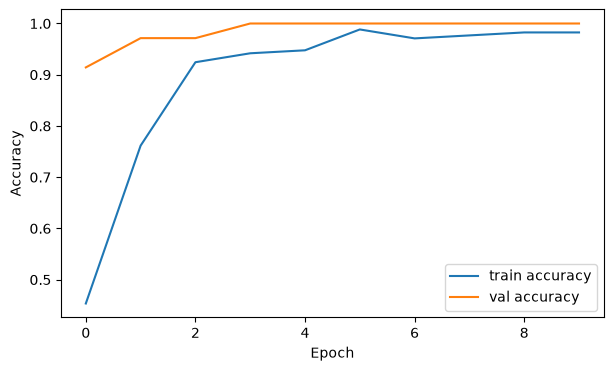

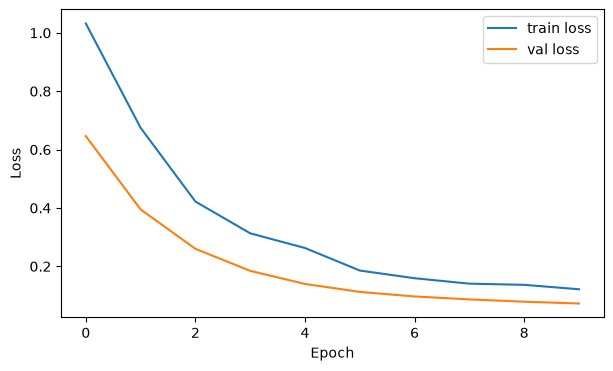

In [11]:
# Completa las cuatro curvas usando el objeto history
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# PUNTO DE CONTROL — FIN DEL TRABAJO EN CLASE

Antes de continuar, verifica que tu equipo tenga:

- [x] 3 clases definidas;
- [x] términos de búsqueda documentados;
- [x] imágenes descargadas;
- [x] dataset inspeccionado y parcialmente limpiado;
- [x] separación `train / validation / test`;
- [x] EfficientNetB0 con pesos de ImageNet;
- [x] backbone congelado;
- [x] nueva cabeza de clasificación;
- [x] al menos un entrenamiento completado;
- [x] `accuracy` y `val_accuracy` reportadas.

## Hasta aquí llega el trabajo de clase.

**No uses todavía el conjunto de test para tomar decisiones.**

---

# PARTE B — TRABAJO EN CASA

A partir de este punto debes completar el análisis de manera autónoma.

Ahora sí vas a:

1. evaluar el modelo en `test`;
2. estudiar la matriz de confusión y métricas por clase;
3. realizar fine-tuning;
4. comparar el modelo congelado contra el modelo ajustado;
5. analizar errores;
6. escribir las conclusiones.

# 7. Evaluación del primer modelo — EN CASA

Ahora sí utilizaremos el conjunto de prueba.

> **Concepto clave — No todo es accuracy**
>
> - **Precision:** de las imágenes que el modelo predijo como una clase, ¿cuántas eran correctas?
> - **Recall:** de las imágenes que realmente pertenecían a una clase, ¿cuántas encontró?
> - **F1:** combina precision y recall.
> - **Matriz de confusión:** muestra qué clases se están confundiendo entre sí.

Guarda esta evaluación: será nuestra línea base antes del fine-tuning.

In [12]:
test_loss_before, test_acc_before = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy antes del fine-tuning: {test_acc_before:.4f}")

Test accuracy antes del fine-tuning: 0.9750


              precision    recall  f1-score   support

     bicycle      0.933     1.000     0.966        14
         bus      1.000     1.000     1.000        11
  motorcycle      1.000     0.933     0.966        15

    accuracy                          0.975        40
   macro avg      0.978     0.978     0.977        40
weighted avg      0.977     0.975     0.975        40



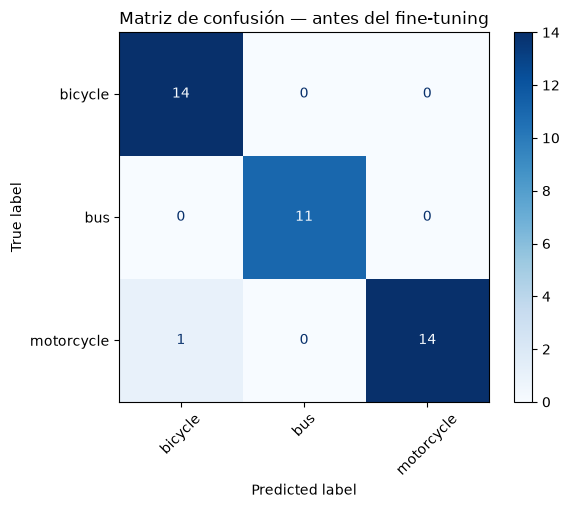

In [13]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    probabilities = model.predict(dataset, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    return y_true, y_pred, probabilities

y_true, y_pred, probabilities = get_predictions(model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — antes del fine-tuning")
plt.show()

## TODO 4 — EN CASA: interpreta la evaluación

Utilizando `classification_report` y la matriz de confusión, responde:

1. ¿Cuál clase obtuvo mejores resultados?
2. ¿Cuál fue la principal confusión?
3. ¿La accuracy global oculta algún problema por clase?
4. ¿Qué cambiarías primero en el **dataset** antes de cambiar el modelo?

**Respuestas (modelo con base congelada, test = 40 imágenes, accuracy = 0.975):**

1. **Mejor clase:** `bus`, con precision, recall y F1 = **1.000** (11/11 sin errores). Es la clase visualmente más distinta: un vehículo grande y rectangular, con muchas ventanas. `bicycle` y `motorcycle` también quedan muy altas (F1 = 0.966).
2. **Principal (y única) confusión:** **una motocicleta clasificada como bicicleta** (`motorcycle/0026`, confianza ≈ 0.50). Es una scooter roja pequeña con canasta delantera, estacionada en una foto en blanco y negro con color selectivo. Por eso recall(motorcycle) = 0.933 y precision(bicycle) = 0.933.
3. **¿La accuracy oculta algo?** En este caso casi no: las tres clases están equilibradas y el F1 macro (0.977) coincide con la accuracy. El problema real es el **tamaño del test**: con 40 imágenes, cada error mueve la accuracy 2.5 puntos, así que 0.975 tiene mucha incertidumbre. Además, la única confusión ocurre justo entre las dos clases de dos ruedas, que es el límite difícil del problema. La accuracy global no deja ver que los buses son "fáciles" y que el riesgo se concentra en bicicleta ↔ moto.
4. **Qué cambiaría primero en el dataset:**
   - Incluir más **scooters, mopeds y motos pequeñas** en `motorcycle`, y más **bicicletas eléctricas o de reparto** en `bicycle`, para cubrir la frontera entre ambas clases.
   - **Diversificar `bus`** para reducir el sesgo de buses rojos de Londres: más buses urbanos de otros países y colores.
   - Reemplazar la búsqueda de paraderos por búsquedas centradas en el vehículo.
   - Ampliar el test para que la métrica sea más confiable.

# 8. Fine-tuning — EN CASA

Ahora permitiremos que una pequeña parte de EfficientNet se adapte al nuevo problema.

> **Concepto clave — Fine-tuning**
>
> En la fase anterior, los pesos del backbone no cambiaron. Ahora descongelaremos únicamente una parte final del modelo y la actualizaremos con un **learning rate mucho menor**.

> **Concepto clave — Batch Normalization**
>
> EfficientNet contiene capas `BatchNormalization`, que mantienen estadísticas internas aprendidas durante el entrenamiento. En datasets pequeños conviene mantenerlas congeladas durante fine-tuning para evitar actualizaciones inestables de esas estadísticas.

Después de cambiar qué capas son entrenables, es necesario **recompilar** el modelo.

In [14]:
base_model.trainable = True

# TODO 5 — Decide cuántas capas finales adaptar.
# Empieza con ~20. Puedes justificar otro valor usando validation.
N_UNFROZEN = 20

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Mantener Batch Normalization congelado.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Capas entrenables de la base:",
    sum(layer.trainable for layer in base_model.layers),
    "/",
    len(base_model.layers),
)

Capas entrenables de la base: 15 / 238


## TODO 5 — EN CASA: realiza fine-tuning

Recompila y continúa el entrenamiento.

Usa como punto de partida:

- `Adam(learning_rate=1e-5)`;
- `SparseCategoricalCrossentropy`;
- `accuracy`;
- entre **3 y 8 épocas** adicionales;
- `EarlyStopping` sobre `val_loss`.

Tu decisión principal aquí es **cuántas capas descongelar**. Justifícala usando el desempeño de validación, no el conjunto de prueba.

**Decisión: `N_UNFROZEN = 20`.** De esas 20 capas finales, 5 son `BatchNormalization` y se mantienen congeladas, así que quedan **15 capas entrenables de 238**: el último bloque MBConv y la convolución final `top_conv`.

**Justificación (usando validation, no test):**
- El modelo congelado ya alcanza **val_accuracy = 1.0** con val_loss = 0.073. Con un margen de mejora tan pequeño, conviene un ajuste **conservador**: adaptar solo las features más específicas (las últimas capas) y mantener intactas las features genéricas de las primeras (bordes, texturas).
- Con solo **172 imágenes de entrenamiento**, descongelar muchas más capas aumenta mucho los parámetros libres y el riesgo de sobreajuste y de "olvidar" lo aprendido en ImageNet.
- Durante el fine-tuning, **val_loss siguió bajando** en las 8 épocas (0.067 → 0.040) y val_accuracy se mantuvo en 1.0, sin señales de inestabilidad. Esto confirma que 20 capas con `lr = 1e-5` es una elección segura.
- Limitación: con 35 imágenes de validación, la val_accuracy ya está saturada en 1.0 y no permite distinguir bien entre alternativas (por ejemplo 20 vs 40 capas). La val_loss es la señal más informativa.

In [15]:
# TODO 5 — EN CASA: completa el fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[early_stopping_ft],
)

Epoch 1/8


C:\Users\jhonp\.venvs\tf312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/6 ━━━━━━━━━━━━━━━━━━━━ 4:26 53s/step - accuracy: 0.9375 - loss: 0.1782

2/6 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9688 - loss: 0.1349   

3/6 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9792 - loss: 0.1175

...

3/6 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.9896 - loss: 0.0654

4/6 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9844 - loss: 0.0693

5/6 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.9875 - loss: 0.0669

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9884 - loss: 0.0711

6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9884 - loss: 0.0711 - val_accuracy: 1.0000 - val_loss: 0.0396


# 9. Comparación final — EN CASA

Compara el desempeño del mismo sistema **antes y después** del fine-tuning.

Una mejora pequeña también puede ser válida. Si el resultado empeora, no significa que el experimento “salió mal”: debes interpretar por qué pudo ocurrir.

**Interpretación:**

| | Base congelada | Después del fine-tuning |
|---|---:|---:|
| Test accuracy | 0.975 | 0.975 |
| F1 macro (test) | 0.977 | 0.977 |
| val_loss final | 0.073 | 0.040 |
| Errores en test | 1 (`motorcycle/0026` → bicycle) | 1 (la misma imagen) |

El fine-tuning **no cambió la accuracy en test (+0.0000)**: el modelo sigue fallando en la misma imagen, e incluso con un poco más de confianza en la clase equivocada (bicycle: 0.50 → 0.54). En general sí **mejoró la confianza** de las predicciones: la val_loss bajó casi a la mitad.

No es un mal resultado. El modelo congelado ya estaba cerca del techo para este dataset: las features de ImageNet separan muy bien estos vehículos, y el único error que queda es un caso **ambiguo / atípico** que no se corrige ajustando pesos, sino con más ejemplos de scooters en el dataset. Además, con 40 imágenes de test, una mejora real de 1–2 puntos sería imposible de medir.

In [16]:
test_loss_after, test_acc_after = model.evaluate(test_ds, verbose=0)
print(f"Antes del fine-tuning  : {test_acc_before:.4f}")
print(f"Después del fine-tuning: {test_acc_after:.4f}")
print(f"Diferencia              : {test_acc_after-test_acc_before:+.4f}")

Antes del fine-tuning  : 0.9750
Después del fine-tuning: 0.9750
Diferencia              : +0.0000


              precision    recall  f1-score   support

     bicycle      0.933     1.000     0.966        14
         bus      1.000     1.000     1.000        11
  motorcycle      1.000     0.933     0.966        15

    accuracy                          0.975        40
   macro avg      0.978     0.978     0.977        40
weighted avg      0.977     0.975     0.975        40



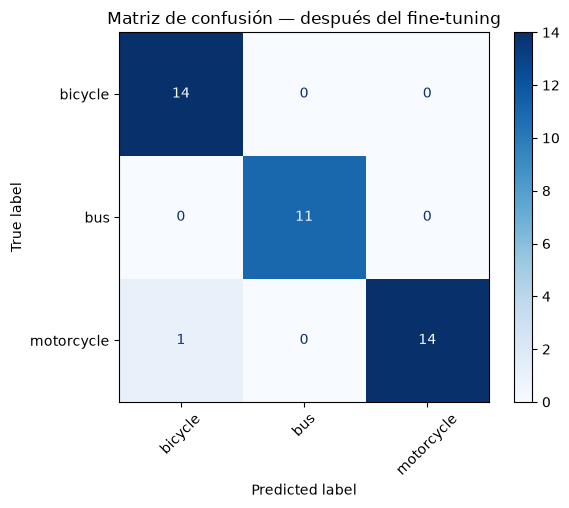

In [17]:
y_true_ft, y_pred_ft, probabilities_ft = get_predictions(model, test_ds)
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names, digits=3))
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — después del fine-tuning")
plt.show()

# 10. Analiza los errores — EN CASA

Una métrica no explica por qué falla un modelo. Debes inspeccionar ejemplos clasificados incorrectamente.

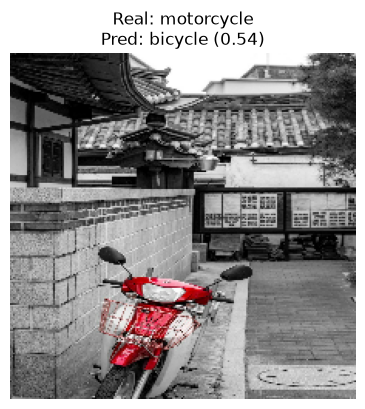

In [18]:
def show_mistakes(dataset, model, class_names, max_images=12):
    mistakes = []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        for image, true_label, pred_label, prob in zip(images.numpy(), labels.numpy(), preds, probs):
            if true_label != pred_label:
                mistakes.append((image.astype("uint8"), int(true_label), int(pred_label), float(prob[pred_label])))
    random.shuffle(mistakes)
    mistakes = mistakes[:max_images]
    if not mistakes:
        print("No se encontraron errores en este conjunto.")
        return
    cols = 4
    rows = int(np.ceil(len(mistakes)/cols))
    plt.figure(figsize=(16, 4*rows))
    for i, (image, true_label, pred_label, confidence) in enumerate(mistakes):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(image)
        ax.set_title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})")
        ax.axis("off")
    plt.tight_layout()

show_mistakes(test_ds, model, class_names)

Casos a analizar: 6

 1. test (antes FT)        motorcycle/0026.jpg   real=motorcycle pred=bicycle    conf=0.50
 2. train (después FT)     bicycle/0048.jpg   real=bicycle    pred=motorcycle conf=0.47
 3. test (después FT)      motorcycle/0026.jpg   real=motorcycle pred=bicycle    conf=0.54
 4. test (acierto dudoso)  bicycle/0061.jpg   real=bicycle    pred=bicycle    conf=0.89
 5. test (acierto dudoso)  bicycle/0038.jpg   real=bicycle    pred=bicycle    conf=0.92
 6. test (acierto dudoso)  bicycle/0042.jpg   real=bicycle    pred=bicycle    conf=0.93


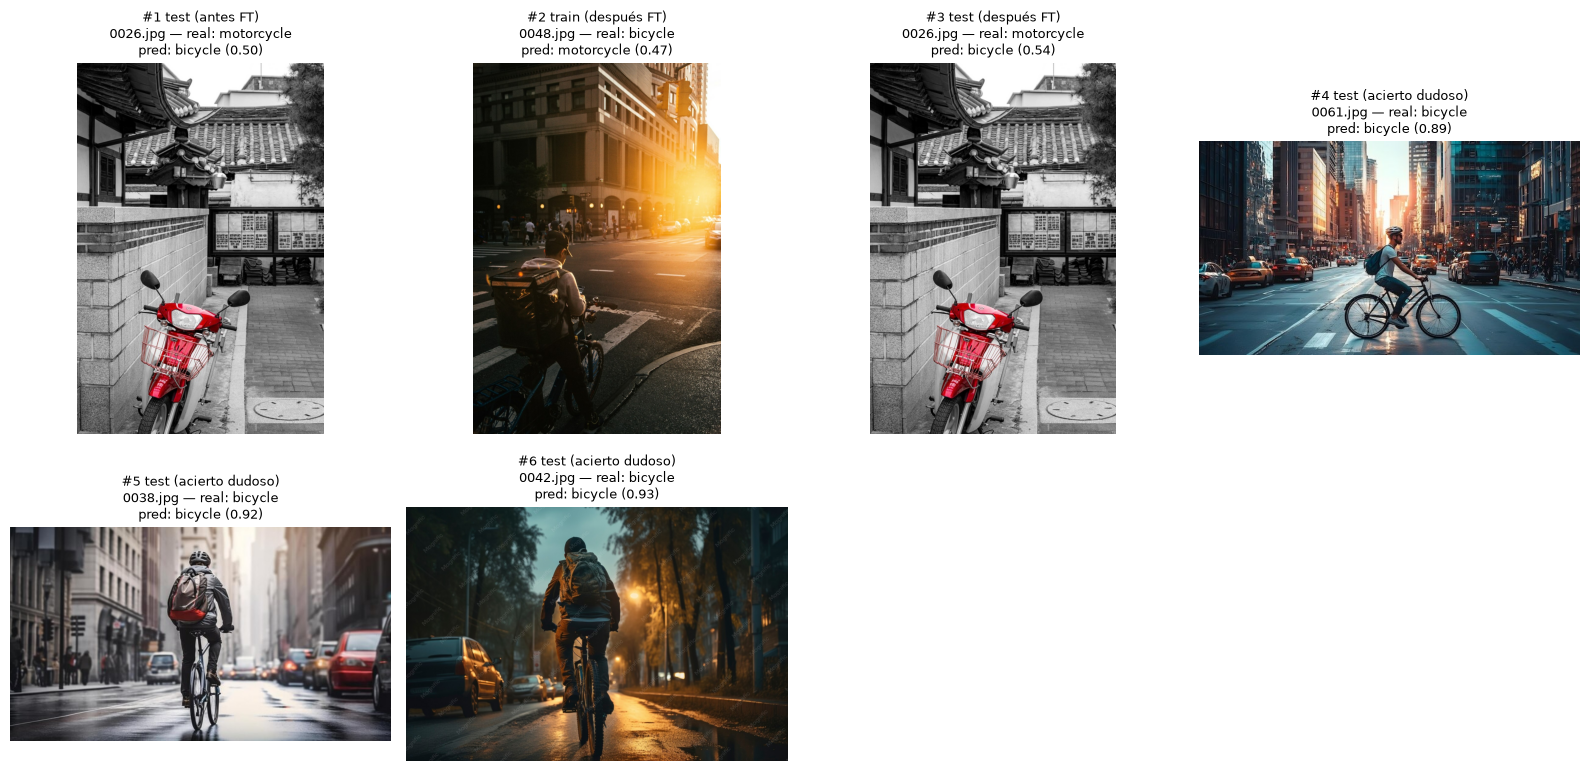

In [19]:
# ERROR_ANALYSIS — Análisis ampliado de errores
# El conjunto de test tiene muy pocos errores, así que para reunir al menos 5 casos
# revisamos también (a) los errores del modelo ANTES del fine-tuning en test,
# (b) los errores del modelo final en train (sin augmentation) y validation, y
# (c) los aciertos de test con menor confianza ("casi errores").
# Nada de esto se usa para tomar decisiones de entrenamiento.

def files_and_labels(split):
    ds = keras.utils.image_dataset_from_directory(
        SPLIT_DIR / split, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        label_mode="int", shuffle=False, verbose=False)
    return ds, ds.file_paths

cases = []

# (a) errores del modelo congelado en test (y_pred se calculó antes del fine-tuning)
_, test_files = files_and_labels("test")
for f, t, p, pr in zip(test_files, y_true, y_pred, probabilities):
    if t != p:
        cases.append(("test (antes FT)", f, t, p, pr[p]))

# (b) errores del modelo final en train / validation / test
for split in ["train", "validation", "test"]:
    ds, files = files_and_labels(split)
    yt = np.concatenate([y.numpy() for _, y in ds])
    pr = model.predict(ds, verbose=0)
    yp = pr.argmax(axis=1)
    for f, t, p, row in zip(files, yt, yp, pr):
        if t != p:
            cases.append((f"{split} (después FT)", f, t, p, row[p]))

# (c) aciertos de test con menor confianza
correct = [(row.max(), f, t) for f, t, p, row in zip(test_files, y_true_ft, y_pred_ft, probabilities_ft) if t == p]
for conf, f, t in sorted(correct)[:3]:
    cases.append(("test (acierto dudoso)", f, t, t, conf))

print(f"Casos a analizar: {len(cases)}\n")
for k, (split, f, t, p, conf) in enumerate(cases, 1):
    print(f"{k:2d}. {split:22s} {Path(f).parent.name}/{Path(f).name:10s} real={class_names[t]:10s} pred={class_names[p]:10s} conf={conf:.2f}")

cols = 4
rows = int(np.ceil(len(cases) / cols))
plt.figure(figsize=(16, 4.2 * rows))
for k, (split, f, t, p, conf) in enumerate(cases, 1):
    ax = plt.subplot(rows, cols, k)
    ax.imshow(Image.open(f).convert("RGB"))
    ax.set_title(f"#{k} {split}\n{Path(f).name} — real: {class_names[t]}\npred: {class_names[p]} ({conf:.2f})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## TODO 6 — EN CASA: análisis de errores y conclusiones

Selecciona al menos **5 errores** del modelo y analiza su causa probable.

| Imagen/error | Clase real | Predicción | Causa probable | ¿Cómo lo mejorarías? |
|---|---|---|---|---|
| 1 — `test/motorcycle/0026` (error, antes y después del FT) | motorcycle | bicycle (0.50 → 0.54) | **Clase visualmente similar / imagen atípica:** es una scooter pequeña tipo *underbone* con **canasta delantera**, perfil delgado y ruedas finas, rasgos típicos de una bicicleta urbana. Además la foto está en blanco y negro con color selectivo, un estilo que casi no aparece en train. | Agregar más scooters, mopeds y motos pequeñas a `motorcycle`; definir explícitamente si los scooters pertenecen a la clase. |
| 2 — `train/bicycle/0048` (error del modelo final) | bicycle | motorcycle (0.47) | **Fondo / contexto engañoso:** un repartidor de noche, a contraluz, con **mochila térmica de delivery**, un contexto que en el dataset aparece más con motos. La bicicleta casi no se ve (oscura y cortada). | Incluir más bicicletas de reparto y escenas nocturnas; recortar o descartar imágenes donde el vehículo no es visible. |
| 3 — `test/bicycle/0061` (acierto con la menor confianza, 0.89) | bicycle | bicycle | **Fondo urbano compartido:** ciclista de lado en una avenida llena de **taxis y autos**. El fondo es el mismo de muchas fotos de buses y motos, y la bicicleta ocupa una parte pequeña de la imagen. | Más ejemplos de bicicletas en entornos variados; *random crop* para que el modelo se fije en el objeto. |
| 4 — `test/bicycle/0038` (acierto dudoso, 0.92) | bicycle | bicycle | **Objeto pequeño / vista trasera:** ciclista de espaldas, y desde atrás solo se ve una línea delgada de la bicicleta. El cuerpo del ciclista (casco, mochila) domina la imagen y es igual al de un motociclista. | Más vistas traseras y frontales de bicicletas (no solo laterales); mayor resolución de entrada. |
| 5 — `test/bicycle/0042` (acierto dudoso, 0.93) | bicycle | bicycle | **Mala iluminación + vista trasera:** escena de atardecer oscura, con el ciclista de espaldas y la bicicleta en sombra. Además es una imagen generada por IA, del mismo estilo que muchas de train, así que el modelo podría apoyarse en ese "estilo". | Balancear la iluminación (más escenas nocturnas en todas las clases) y reducir las imágenes sintéticas; augmentation de brillo y contraste. |

> **Nota:** el modelo final solo comete **2 errores reales** en las 247 imágenes (1 en test y 1 en train), y ninguno en validation. Para completar 5 casos se analizaron también los **3 aciertos de test con menor confianza**: no son errores, pero muestran dónde el modelo es más frágil. Los casos están en la celda de análisis ampliado de errores.

Posibles causas: imagen ambigua, etiqueta incorrecta, objeto pequeño, oclusión, fondo engañoso, clase visualmente similar, mala calidad, sesgo del dataset o error razonable del modelo.

Después, escribe una conclusión breve respondiendo:

1. ¿Qué aprendiste al construir el dataset?
2. ¿Cuál fue el principal problema de calidad?
3. ¿Cuánto cambió el desempeño después del fine-tuning?
4. ¿El fine-tuning ayudó? ¿Por qué crees que sí o no?
5. ¿Qué mejorarías primero: datos, entrenamiento o arquitectura?

### Conclusiones

1. **¿Qué aprendí al construir el dataset?** Que la calidad depende más de **los términos de búsqueda** que del número de resultados. Una sola búsqueda mal planteada (*"bus stop"*) llenó la clase `bus` de paraderos vacíos. También aprendí que la validación técnica (que TensorFlow pueda leer la imagen) no garantiza la validación semántica: hubo que revisar **todas** las imágenes a mano. Además, un buscador trae **sesgos de estilo** que no son errores pero pueden dar atajos al modelo: fotos de stock, marcas de agua, imágenes generadas por IA, buses rojos de Londres.
2. **Principal problema de calidad:** imágenes donde **el objeto no aparece o no es una fotografía** (paraderos sin bus, renders, dibujos, collages e infografías): 57 de 304 imágenes (19 %) eliminadas, además de 2 etiquetas incorrectas y 2 casi-duplicados.
3. **¿Cuánto cambió el desempeño con el fine-tuning?** En test, **nada: 0.975 → 0.975** (F1 macro 0.977 en ambos casos, el mismo único error). En validation, la accuracy se mantuvo en 1.0 y la **val_loss bajó de 0.073 a 0.040**, es decir, el modelo quedó más seguro de sus predicciones.
4. **¿Ayudó el fine-tuning?** Solo marginalmente: mejoró la confianza, pero no la accuracy. Las features de ImageNet ya bastan para separar estas tres clases (ImageNet contiene clases de bicicletas, motos y buses), y el error que queda se debe a una **imagen atípica** (scooter con canasta), no a features poco adaptadas. Además, con 40 imágenes de test, una mejora pequeña no sería medible.
5. **¿Qué mejoraría primero?** **Los datos.** El modelo y el entrenamiento ya funcionan bien. Los límites actuales son la cobertura de los casos frontera (scooters, bicicletas eléctricas o de reparto, vistas traseras, escenas nocturnas), el sesgo de los buses londinenses y el tamaño del test. Cambiar la arquitectura sería lo último.

# Extensión opcional — Prueba con una imagen externa

Busca una imagen que **no esté en tu dataset** y prueba el modelo. Esta parte no cuenta como un TODO principal, pero sirve como comprobación cualitativa de generalización.

In [20]:
# OPCIONAL
# EXTERNAL_IMAGE_URL = "https://..."
# response = requests.get(EXTERNAL_IMAGE_URL, timeout=10)
# response.raise_for_status()
# img = Image.open(io.BytesIO(response.content)).convert("RGB")
# img_resized = img.resize(IMG_SIZE)
# x = np.array(img_resized, dtype="float32")[None, ...]
# p = model.predict(x, verbose=0)[0]
# plt.imshow(img)
# plt.axis("off")
# plt.title(f"{class_names[p.argmax()]} — confianza {p.max():.2f}")
# plt.show()

# 🏠 Cierre conceptual — ENTREGA

Como parte del **TODO 6**, explica con tus propias palabras la diferencia entre:

- **feature extraction / transfer learning con base congelada**;
- **fine-tuning**;
- **entrenar una CNN desde cero**.

No describas solo el código. Explica **qué parámetros se están aprendiendo y de dónde viene el conocimiento inicial**.

**Respuesta:**

- **Transfer learning con base congelada (feature extraction):** el conocimiento inicial viene de **ImageNet**: EfficientNetB0 ya aprendió, con ~1.2 millones de imágenes, a detectar bordes, texturas, formas y partes de objetos. Esos ~4 millones de pesos se **congelan** y la red funciona como un extractor fijo de features (un vector de 1280 valores por imagen). Solo se aprenden los parámetros de la **nueva cabeza**: la `Dense(3)`, con 3843 parámetros. Es rápido, necesita pocos datos y casi no sobreajusta, pero las features no se adaptan al problema.
- **Fine-tuning:** se parte del modelo anterior (backbone de ImageNet + cabeza ya entrenada) y se **descongelan las últimas capas** del backbone, en nuestro caso 15 capas del último bloque, que se reentrenan junto con la cabeza usando un **learning rate muy pequeño** (1e-5). Así, las features más específicas (de alto nivel) se **ajustan ligeramente** a bicicletas, buses y motos, sin destruir lo aprendido. Las capas iniciales y las estadísticas de BatchNormalization siguen congeladas. Aprende más parámetros, así que es más potente pero también más propenso a sobreajustar con pocos datos.
- **Entrenar una CNN desde cero:** **no hay conocimiento previo**. Todos los pesos se inicializan al azar y se aprenden únicamente con nuestras imágenes, desde los filtros de bordes hasta la capa de salida. Con 172 imágenes de entrenamiento, una red de millones de parámetros memorizaría el train y generalizaría mal. Para que funcione necesita muchos más datos, más tiempo de cómputo y fuerte regularización y augmentation.

# Reto opcional

Elige **uno**:

**A. Más datos:** duplica el número de imágenes manteniendo el modelo igual.  
**B. Otro backbone:** prueba MobileNetV3, ResNet50 o EfficientNetV2B0.  
**C. Dataset difícil:** agrega una cuarta clase visualmente parecida.  
**D. Ablation:** entrena sin `data_augmentation` y compara.

Cambia **una sola variable a la vez**.

# ✅ Checklist de entrega

Antes de entregar verifica:

### Evidencia del trabajo en clase
- [x] Problema y clases definidos.
- [x] Dataset construido y revisado.
- [x] Train / validation / test creados.
- [x] Primer modelo con backbone congelado entrenado.

### Trabajo en casa
- [x] Evaluación sobre test.
- [x] Matriz de confusión.
- [x] Precision / recall / F1 interpretados.
- [x] Fine-tuning ejecutado.
- [x] Comparación antes vs. después del fine-tuning.
- [x] Al menos 5 errores analizados.
- [x] Conclusión final escrita.

### Opcional
- [ ] Imagen externa.
- [ ] Experimento adicional / reto.

# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| TODO 1 — Problema y estrategia de búsqueda | 10% |
| TODO 2 — Construcción, inspección y limpieza del dataset | 20% |
| Split y pipeline de datos | 10% |
| TODO 3 — Transfer learning + curvas | 20% |
| TODO 4 — Evaluación e interpretación | 10% |
| TODO 5 — Fine-tuning y comparación | 15% |
| TODO 6 — Análisis de errores + conclusión conceptual | 15% |
| **Total** | **100%** |